
Running N = 500
Mean = 0.9965, Std = 0.0011

Running N = 1000
Mean = 0.9973, Std = 0.0009

Running N = 2000
Mean = 0.9984, Std = 0.0004

Running N = 5000
Mean = 0.9991, Std = 0.0002

Running N = 10000
Mean = 0.9995, Std = 0.0001


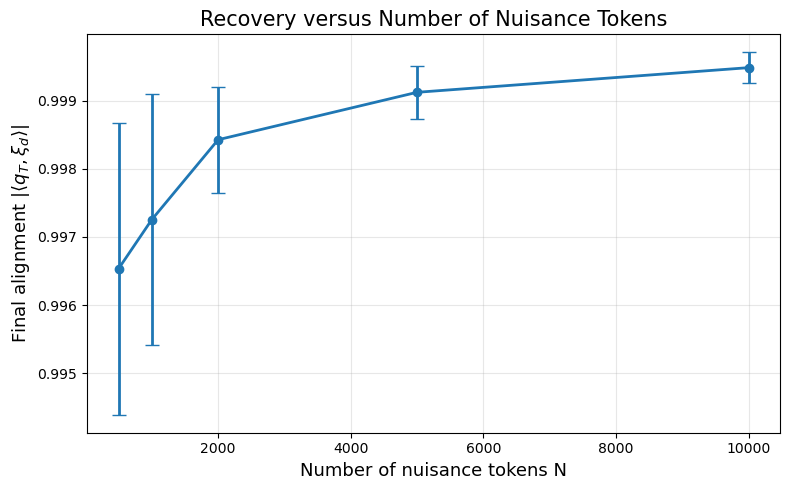


Summary
------------------------------
N=  500   mean=0.9965   std=0.0011
N= 1000   mean=0.9973   std=0.0009
N= 2000   mean=0.9984   std=0.0004
N= 5000   mean=0.9991   std=0.0002
N=10000   mean=0.9995   std=0.0001


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# Parameters
# =====================================================

d = 50

R = 500

N_values = [500, 1000, 2000, 5000, 10000]

theta = 2.0
beta = 1.0

T = 5000

eta0 = 0.5
alpha = 0.6

num_trials = 30

# =====================================================
# One run
# =====================================================

def run_trial(seed, N):

    np.random.seed(seed)

    xi = np.random.randn(d)
    xi /= np.linalg.norm(xi)

    q = np.random.randn(d)
    q /= np.linalg.norm(q)

    for t in range(T):

        eta = eta0 / ((t + 1) ** alpha)

        # informative tokens
        X_inf = theta * xi + np.random.randn(R, d)

        # nuisance tokens
        X_noise = np.random.randn(N, d)

        X = np.vstack([X_inf, X_noise])

        # softmax attention
        logits = beta * (X @ q)

        logits -= np.max(logits)

        weights = np.exp(logits)

        a = weights / np.sum(weights)

        # attention output
        f = np.sum(a[:, None] * X, axis=0)

        # gradient
        inner = X @ f

        g = (
            2.0
            * beta
            * np.sum(
                a[:, None]
                * inner[:, None]
                * (X - f),
                axis=0
            )
        )

        # projection
        q_new = q + eta * g

        q = q_new / np.linalg.norm(q_new)

    return abs(np.dot(q, xi))

# =====================================================
# Main experiment
# =====================================================

means = []
stds = []

for N in N_values:

    print(f"\nRunning N = {N}")

    final_alignments = []

    for seed in range(num_trials):

        final_alignment = run_trial(seed, N)

        final_alignments.append(final_alignment)

    final_alignments = np.array(final_alignments)

    means.append(np.mean(final_alignments))
    stds.append(np.std(final_alignments))

    print(
        "Mean = %.4f, Std = %.4f"
        % (
            np.mean(final_alignments),
            np.std(final_alignments)
        )
    )

means = np.array(means)
stds = np.array(stds)

# =====================================================
# Plot
# =====================================================

plt.figure(figsize=(8,5))

plt.errorbar(
    N_values,
    means,
    yerr=2*stds,
    marker='o',
    linewidth=2,
    capsize=5
)

plt.xlabel("Number of nuisance tokens N", fontsize=13)

plt.ylabel(
    r"Final alignment $|\langle q_T,\xi_d\rangle|$",
    fontsize=13
)

plt.title(
    "Recovery versus Number of Nuisance Tokens",
    fontsize=15
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

# =====================================================
# Table
# =====================================================

print("\nSummary")
print("------------------------------")

for N, m, s in zip(N_values, means, stds):

    print(
        f"N={N:5d}   mean={m:.4f}   std={s:.4f}"
    )